# UnivarGD

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
# UnivarGD
def cost(x):
    return x ** 2 + 5 * np.sin(x)
def grad(x):
    return 2 * x + 5 * np.cos(x)
def myGD1(x0, eta):
    x = [x0]
    it = None
    for it in range(100):
        x_new = x[-1] - eta * grad(x[-1])
        if abs(grad(x_new)) < 1e-3:
            break
        x.append(x_new)
    return (np.array(x), it)

(x1, it1) = myGD1(-5, 0.1)
(x2, it2) = myGD1(5, 0.1)

# Solving linear regression by MultiGD

In [38]:
from sklearn.linear_model import LinearRegression

X = np.random.rand(1000, 1)
y = 4 + 3 * X + .5*np.random.randn(1000, 1)
model = LinearRegression()
model.fit(X, y)
sol_sklearn = np.array([model.intercept_[0], model.coef_[0][0]])
print('Solution found by sklearn : ', sol_sklearn)


Solution found by sklearn :  [4.00833181 2.9623299 ]


![](images/sklearn_linear_model.png)

Shape of w is (1, 1)
Shape of b is (1,)
Shape of X is (1, 1000)
Shape of y is (1000, 1)


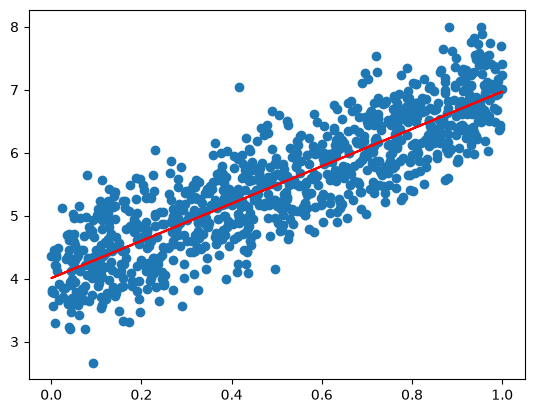

In [44]:
#Plot soluiton found by sklearn
plt.scatter(X, y)
w, b = model.coef_, model.intercept_
print(f'Shape of w is {w.shape}\nShape of b is {b.shape}\nShape of X is {X.T.shape}\nShape of y is {y.shape}')
y_head = X @ w + b
plt.plot(X, y_head, color='red')
plt.show()

In [43]:
# MultiGD
one = np.ones((X.shape[0], 1), dtype=X.dtype)
Xbar = np.concat((one, X), axis=1)
N = Xbar.shape[0]
def grad(w):
    return 1 / N * (Xbar.T @ (Xbar @ w - y))
def cost(w):
    return 0.5 * np.linalg.norm(y - Xbar @ w) ** 2
def multiGD(w0, eta):
    w = [w0]
    it = 0
    for it in range(1000):
        w_new = w[-1] - eta * grad(w[-1])
        if np.linalg.norm(grad(w[-1])) < 1e-10:
            break
        w.append(w_new)
    return w, it

w_init = np.array([[2], [1]])
w1, it1 = multiGD(w_init, 1)
print('Sol found by GD: w = ', w1[-1].T , f' after {it1} iterations')

Sol found by GD: w =  [[4.00833181 2.9623299 ]]  after 294 iterations


In [51]:
# Momentum
def GD_momentum(grad, theta_0, eta, gamma):
    theta = [theta_0]
    v_old = np.zeros_like(theta_0)
    it = None
    for it in range(1000):
        v_new = gamma * v_old + eta * grad(theta[-1])
        theta_new = theta[-1] - v_new
        if np.linalg.norm(grad(theta_new)) < 1e-5:
            break
        theta.append(theta_new)
        v_old = v_new
    return theta, it
w2, it2 = GD_momentum(grad, w_init, 1, 0.3)
print(w2[-1].T, ' ', it2)

[[4.00840746]
 [2.9621916 ]]   82


In [52]:
# Nesterov accelerated gradient
def GD_NAG(grad, theta_init, eta, gamma):
    theta = [theta_init]
    v = [np.zeros_like(theta_init)]
    for it in range(100):
        v_new = gamma*v[-1] + eta*grad(theta[-1] - gamma*v[-1])
        theta_new = theta[-1] - v_new
        if np.linalg.norm(grad(theta_new))/np.array(theta_init).size < 1e-3:
            break
        theta.append(theta_new)
        v.append(v_new)
    return theta

w3 = GD_NAG(grad, w_init, 1, 0.3)
print('Sol found by NAG: w = ', w3[-1].T, f' after {len(w3) - 1} iterations')

Sol found by NAG: w =  [[4.02368945 2.93425292]]  after 32 iterations


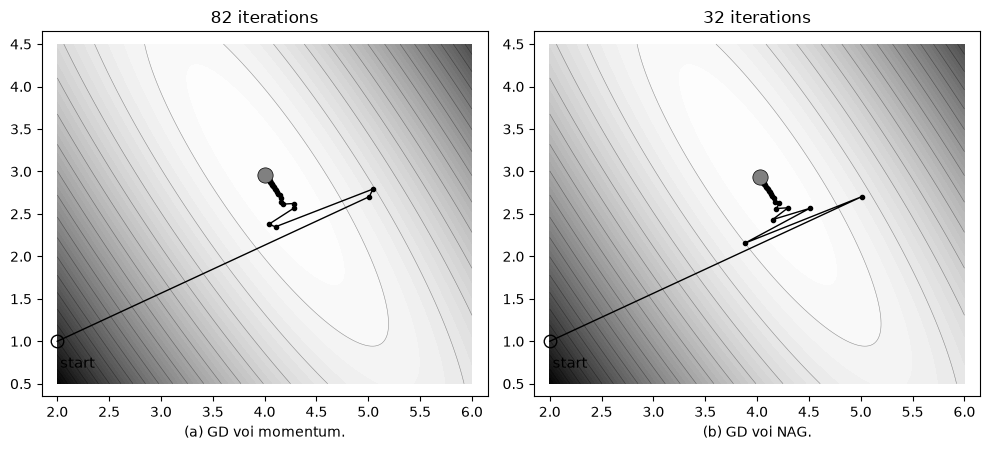

In [59]:
# Minh hoa duong di cua nghiem tren mat loss 
# J(w) = 1/2||y - Xbar w||^2, khai trien thanh dang toan phuong de tinh ca luoi cung luc
def cost_on_grid(w0_rng, w1_rng, n = 250):
    g0 = np.linspace(*w0_rng, n)
    g1 = np.linspace(*w1_rng, n)
    W0, W1 = np.meshgrid(g0, g1)
    A = Xbar.T @ Xbar
    c = (Xbar.T @ y).ravel()
    const = 0.5 * float(np.sum(y ** 2))
    Z = 0.5 * (A[0, 0] * W0**2 + 2 * A[0, 1] * W0 * W1 + A[1, 1] * W1**2) \
        - (c[0] * W0 + c[1] * W1) + const
    return W0, W1, Z

w0_rng, w1_rng = (2, 6), (0.5, 4.5)
W0, W1, Z = cost_on_grid(w0_rng, w1_rng)

def plot_path(ax, hist, caption, pad = 0.15):
    P = np.hstack([np.asarray(h).reshape(2, 1) for h in hist])       # (2, K)
    ax.contourf(W0, W1, Z, levels = 60, cmap = 'gray_r')             # nen: toi = loss cao
    ax.contour(W0, W1, Z, levels = 20, colors = 'k',
               linewidths = 0.4, alpha = 0.4)                        # cac duong dong muc
    ax.plot(P[0], P[1], 'k-', lw = 1)                                # duong noi cac buoc
    ax.plot(P[0][1:-1], P[1][1:-1], 'ko', ms = 3)                    # cac buoc trung gian
    ax.plot(P[0][0], P[1][0], 'o', mfc = 'none', mec = 'k', ms = 9)  # diem xuat phat
    ax.annotate('start', (P[0][0], P[1][0]), textcoords = 'offset points',
                xytext = (2, -19), ha = 'left', fontsize = 11)
    ax.plot(P[0][-1], P[1][-1], 'o', color = 'gray', ms = 11, mec = 'k', mew = 0.5)
    ax.set_xlim(w0_rng[0] - pad, w0_rng[1] + pad)     # chua le de thay tron diem start
    ax.set_ylim(w1_rng[0] - pad, w1_rng[1] + pad)
    ax.set_title(f'{len(hist) - 1} iterations')
    ax.set_xlabel(caption)

fig, axes = plt.subplots(1, 2, figsize = (10, 4.6))
plot_path(axes[0], w2, '(a) GD voi momentum.')
plot_path(axes[1], w3, '(b) GD voi NAG.')
plt.tight_layout()
plt.show()